<a href="https://colab.research.google.com/github/Ansh971/lung-nodule-detection/blob/main/Lungs_detection_Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)
else:
    print("GPU not detect")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Name: Tesla T4
CUDA Version: 12.8


In [ ]:
# Install required libraries for the project

!pip install -q SimpleITK pydicom scikit-learn matplotlib seaborn pandas numpy opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 96.6 MB/s eta 0:00:00


In [ ]:
import os

# Project folders
folders = [
    "/content/lung_cancer_project",
    "/content/lung_cancer_project/data",
    "/content/lung_cancer_project/models",
    "/content/lung_cancer_project/results",
    "/content/lung_cancer_project/plots"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Project folders created successfully!")

for folder in folders:
    print(folder)

✅ Project folders created successfully!
/content/lung_cancer_project
/content/lung_cancer_project/data
/content/lung_cancer_project/models
/content/lung_cancer_project/results
/content/lung_cancer_project/plots


In [ ]:
import shutil

total, used, free = shutil.disk_usage("/content")

print("Total Storage :", round(total / (1024**3), 2), "GB")
print("Used Storage  :", round(used / (1024**3), 2), "GB")
print("Free Storage  :", round(free / (1024**3), 2), "GB")

Total Storage : 112.64 GB
Used Storage  : 47.34 GB
Free Storage  : 65.28 GB


In [ ]:
import os
os.makedirs("/content/lung_cancer_project/data/luna16", exist_ok=True)
!curl "https://zenodo.org/records/2604219/files/subset0.zip?download=1" \
 -o /content/lung_cancer_project/data/download.log \
 -O /content/lung_cancer_project/data/luna16/subset0.zip
print("✅ Download command completed!")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
 20 6496M   20 1342M    0     0  2412k      0  0:45:57  0:09:29  0:36:28 4008k^C
✅ Download command completed!


In [ ]:
import os

zip_path = "/content/lung_cancer_project/data/luna16/subset0.zip"

print("File exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    print("File size:", os.path.getsize(zip_path) / (1024 * 1024), "MB")


File exists: False


In [ ]:
!file /content/lung_cancer_project/data/luna16/subset0.zip


/content/lung_cancer_project/data/luna16/subset0.zip: cannot open `/content/lung_cancer_project/data/luna16/subset0.zip' (No such file or directory)


In [ ]:
import os

base = "/content/lung_cancer_project/data/luna16"
os.makedirs(base, exist_ok=True)

print("Folder:", base)
print("Files:", os.listdir(base))

Folder: /content/lung_cancer_project/data/luna16
Files: []


In [ ]:
!wget -O /content/lung_cancer_project/data/luna16/subset0.zip \
"https://zenodo.org/records/2604219/files/subset0.zip?download=1"


--2026-10-05 11:41:35--  https://zenodo.org/records/2604219/files/subset0.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6811924508 (6.3G) [application/octet-stream]
Saving to: ‘/content/lung_cancer_project/data/luna16/subset0.zip’

/content/lung_cance 100%[===================>]   6.34G  30.1MB/s    in 5m 50s  

2026-10-05 11:47:25 (18.6 MB/s) - ‘/content/lung_cancer_project/data/luna16/subset0.zip’ saved [6811924508/6811924508]



In [ ]:
import os

zip_path = "/content/lung_cancer_project/data/luna16/subset0.zip"

if os.path.exists(zip_path):
    size = os.path.getsize(zip_path) / (1024 * 1024)
    print(f" ZIP found!")
    print(f"Size: {size:.2f} MB")
else:
    print(" ZIP not download")

 ZIP found!
Size: 6496.36 MB


In [ ]:
!file /content/lung_cancer_project/data/luna16/subset0.zip

/content/lung_cancer_project/data/luna16/subset0.zip: Zip archive data, at least v2.0 to extract, compression method=deflate


In [ ]:
import zipfile

zip_path = "/content/lung_cancer_project/data/luna16/subset0.zip"
extract_path = "/content/lung_cancer_project/data/luna16/subset0"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [ ]:
import os

dataset_path = "/content/lung_cancer_project/data/luna16/subset0"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Files:", files[:5])
    print("-" * 50)

Folder: /content/lung_cancer_project/data/luna16/subset0
Files: []
--------------------------------------------------
Folder: /content/lung_cancer_project/data/luna16/subset0/subset0
Files: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.724251104254976962355686318345.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.805925269324902055566754756843.raw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.187451715205085403623595258748.raw', '1.3.6.1.4.1.14519.5.2.1.6279.6001.126121460017257137098781143514.mhd', '1.3.6.1.4.1.14519.5.2.1.6279.6001.139258777898746693365877042411.raw']
--------------------------------------------------


In [ ]:
!pip install SimpleITK -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.4 MB/s eta 0:00:00


In [ ]:
import SimpleITK as sitk
import os

dataset_path = "/content/lung_cancer_project/data/luna16/subset0/subset0"

mhd_files = [
    f for f in os.listdir(dataset_path)
    if f.endswith(".mhd")
]

print("Total CT scans:", len(mhd_files))
print("First CT scan:", mhd_files[0])

Total CT scans: 89
First CT scan: 1.3.6.1.4.1.14519.5.2.1.6279.6001.724251104254976962355686318345.mhd


In [ ]:
mhd_file = os.path.join(dataset_path, mhd_files[0])

image = sitk.ReadImage(mhd_file)
image_array = sitk.GetArrayFromImage(image)

print("CT scan loaded successfully!")
print("Shape:", image_array.shape)
print("Minimum HU:", image_array.min())
print("Maximum HU:", image_array.max())

CT scan loaded successfully!
Shape: (392, 512, 512)
Minimum HU: -1000
Maximum HU: 3000


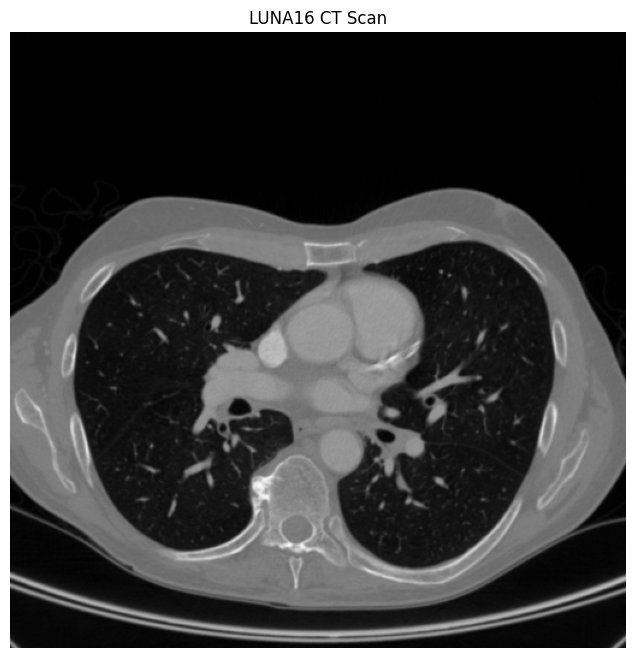

In [ ]:
import matplotlib.pyplot as plt

middle_slice = image_array.shape[0] // 2

plt.figure(figsize=(8, 8))
plt.imshow(image_array[middle_slice], cmap="gray")
plt.title("LUNA16 CT Scan")
plt.axis("off")
plt.show()

In [ ]:
import requests
import os

url = "https://zenodo.org/records/3723295/files/annotations.csv?download=1"
output = "/content/lung_cancer_project/data/annotations.csv"

os.makedirs(os.path.dirname(output), exist_ok=True)

response = requests.get(url)
print("Status:", response.status_code)

with open(output, "wb") as f:
    f.write(response.content)

print("✅ annotations.csv downloaded")
print("Size:", os.path.getsize(output) / 1024, "KB")

Status: 200
✅ annotations.csv downloaded
Size: 133.775390625 KB


In [ ]:
import pandas as pd

annotations_path = "/content/lung_cancer_project/data/annotations.csv"

annotations = pd.read_csv(annotations_path)

print("Rows:", len(annotations))
print("Columns:")
print(annotations.columns.tolist())

annotations.head()

Rows: 1186
Columns:
['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


In [ ]:
import glob
import os

mhd_files = glob.glob(
    "/content/lung_cancer_project/data/luna16/subset0/subset0/*.mhd"
)

series_ids = [
    os.path.splitext(os.path.basename(f))[0]
    for f in mhd_files
]

print("CT scans:", len(series_ids))
print("Annotated scans available:", annotations["seriesuid"].isin(series_ids).sum())

CT scans: 89
Annotated scans available: 112


In [ ]:
matched = annotations[
    annotations["seriesuid"].isin(series_ids)
]

print("Matched annotations:", len(matched))
matched.head()


Matched annotations: 112


,seriesuid,coordX,coordY,coordZ,diameter_mm
23,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,-100.567944,67.260517,-231.816619,6.440879
25,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,46.188539,48.402806,-108.578632,13.596471
26,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,36.392044,76.771663,-123.321911,4.343200
28,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,136.434059,117.765579,-181.947817,4.681382
86,1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048...,145.967465,-161.197634,-312.071347,6.378436


In [ ]:
if len(matched) > 0:
    first_nodule = matched.iloc[0]

    print("Series ID:", first_nodule["seriesuid"])
    print("X:", first_nodule["coordX"])
    print("Y:", first_nodule["coordY"])
    print("Z:", first_nodule["coordZ"])
    print("Diameter:", first_nodule["diameter_mm"], "mm")
else:
    print(" No matching annotations found.")

Series ID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492
X: -100.5679445
Y: 67.26051683
Z: -231.816619
Diameter: 6.440878725 mm


In [ ]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import os

series_id = first_nodule["seriesuid"]

mhd_path = os.path.join(
    dataset_path,
    series_id + ".mhd"
)

print("Looking for:")
print(mhd_path)
print("Exists:", os.path.exists(mhd_path))

Looking for:
/content/lung_cancer_project/data/luna16/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd
Exists: True


In [ ]:
image = sitk.ReadImage(mhd_path)

volume = sitk.GetArrayFromImage(image)

print("CT volume shape:", volume.shape)
print("Spacing:", image.GetSpacing())
print("Origin:", image.GetOrigin())

CT volume shape: (119, 512, 512)
Spacing: (0.7421879768371582, 0.7421879768371582, 2.5)
Origin: (-182.5, -190.0, -313.75)


In [ ]:
world_point = (
    float(first_nodule["coordX"]),
    float(first_nodule["coordY"]),
    float(first_nodule["coordZ"])
)

voxel_point = image.TransformPhysicalPointToIndex(world_point)

print("World coordinates:")
print(world_point)

print("\nVoxel coordinates:")
print(voxel_point)

World coordinates:
(-100.5679445, 67.26051683, -231.816619)

Voxel coordinates:
(110, 347, 33)


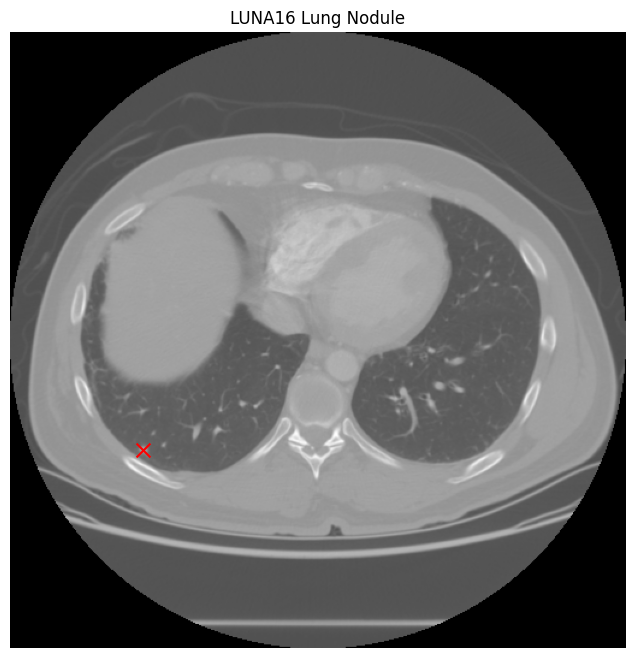

In [ ]:
x, y, z = voxel_point

plt.figure(figsize=(8, 8))

plt.imshow(
    volume[z],
    cmap="gray"
)

plt.scatter(
    x,
    y,
    c="red",
    s=100,
    marker="x"
)

plt.title("LUNA16 Lung Nodule")
plt.axis("off")
plt.show()

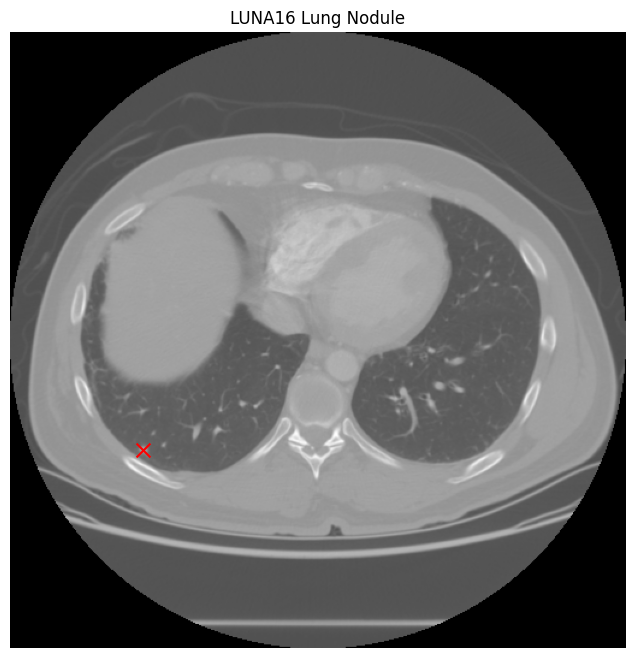

In [ ]:
x, y, z = voxel_point

plt.figure(figsize=(8, 8))

plt.imshow(
    volume[z],
    cmap="gray"
)

plt.scatter(
    x,
    y,
    c="red",
    s=100,
    marker="x"
)

plt.title("LUNA16 Lung Nodule")
plt.axis("off")
plt.show()

In [ ]:
patch_size = 64
half = patch_size // 2

patch = volume[
    z,
    y-half:y+half,
    x-half:x+half
]

print("Patch shape:", patch.shape)

Patch shape: (64, 64)


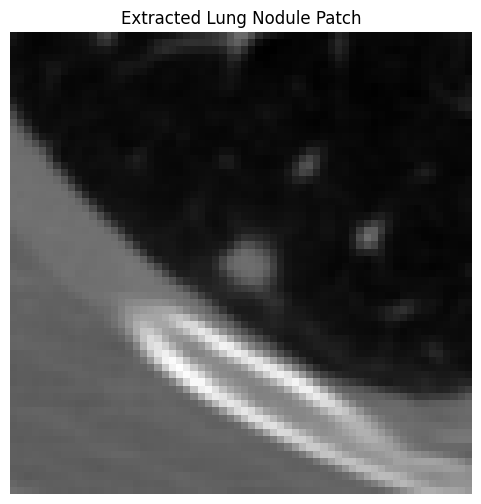

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(patch, cmap="gray")

plt.title("Extracted Lung Nodule Patch")
plt.axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np

def preprocess_patch(patch, size=(64, 64)):
    # Resize
    patch = cv2.resize(patch, size)

    # Normalize
    patch = patch.astype(np.float32)

    min_val = patch.min()
    max_val = patch.max()

    if max_val > min_val:
        patch = (patch - min_val) / (max_val - min_val)
    else:
        patch = np.zeros_like(patch)

    return patch

In [ ]:
processed_patch = preprocess_patch(patch)

print("Shape:", processed_patch.shape)
print("Min:", processed_patch.min())
print("Max:", processed_patch.max())

Shape: (64, 64)
Min: 0.0
Max: 1.0


In [ ]:
matched = annotations[
    annotations["seriesuid"].isin(series_ids)
]

print("Total matched annotations:", len(matched))

Total matched annotations: 112


In [ ]:
matched.head(10)

,seriesuid,coordX,coordY,coordZ,diameter_mm
23,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896...,-100.567944,67.260517,-231.816619,6.440879
25,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,46.188539,48.402806,-108.578632,13.596471
26,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524...,36.392044,76.771663,-123.321911,4.343200
28,1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674...,136.434059,117.765579,-181.947817,4.681382
86,1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048...,145.967465,-161.197634,-312.071347,6.378436
98,1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931...,59.114146,-158.577253,-118.037336,6.720277
103,1.3.6.1.4.1.14519.5.2.1.6279.6001.128023902651...,33.832826,88.411590,-101.780481,10.462608
110,1.3.6.1.4.1.14519.5.2.1.6279.6001.129055977637...,-96.469304,-88.128962,1131.113774,6.800249
117,1.3.6.1.4.1.14519.5.2.1.6279.6001.130438550890...,88.231452,32.809117,-77.986386,5.059407
129,1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583...,-84.046581,-42.015360,-146.807400,7.053720


In [ ]:
def extract_nodule_patch(image, annotation, patch_size=64):

    world_point = (
        float(annotation["coordX"]),
        float(annotation["coordY"]),
        float(annotation["coordZ"])
    )

    voxel_point = image.TransformPhysicalPointToIndex(world_point)

    x, y, z = voxel_point

    volume = sitk.GetArrayFromImage(image)

    half = patch_size // 2

    # Boundary check
    if (
        z < 0 or z >= volume.shape[0] or
        y-half < 0 or y+half > volume.shape[1] or
        x-half < 0 or x+half > volume.shape[2]
    ):
        return None

    patch = volume[
        z,
        y-half:y+half,
        x-half:x+half
    ]

    return preprocess_patch(patch)


In [ ]:
import os

positive_dir = "/content/lung_cancer_project/data/positive"

os.makedirs(positive_dir, exist_ok=True)

print(" Positive folder created")

 Positive folder created


In [ ]:
positive_patches = []

for index, row in matched.iterrows():

    series_id = row["seriesuid"]

    mhd_path = os.path.join(
        dataset_path,
        series_id + ".mhd"
    )

    if not os.path.exists(mhd_path):
        continue

    image = sitk.ReadImage(mhd_path)

    patch = extract_nodule_patch(image, row)

    if patch is not None:
        positive_patches.append(patch)

print("Positive patches extracted:", len(positive_patches))

Positive patches extracted: 112


In [ ]:
for i, p in enumerate(positive_patches):

    np.save(
        f"{positive_dir}/positive_{i}.npy",
        p
    )

print(" Positive patches saved")

 Positive patches saved


In [ ]:
!ls /content/lung_cancer_project/data/positive | head

positive_0.npy
positive_100.npy
positive_101.npy
positive_102.npy
positive_103.npy
positive_104.npy
positive_105.npy
positive_106.npy
positive_107.npy
positive_108.npy


In [ ]:
import os

negative_dir = "/content/lung_cancer_project/data/negative"
os.makedirs(negative_dir, exist_ok=True)

print(" Negative folder created")

 Negative folder created


In [ ]:
import random
import numpy as np
import SimpleITK as sitk

def extract_negative_patches(image, annotation_rows, num_patches=5, patch_size=64):

    volume = sitk.GetArrayFromImage(image)

    patches = []

    # Known nodule voxel coordinates
    nodule_voxels = []

    for _, row in annotation_rows.iterrows():
        world_point = (
            float(row["coordX"]),
            float(row["coordY"]),
            float(row["coordZ"])
        )

        voxel = image.TransformPhysicalPointToIndex(world_point)
        nodule_voxels.append(voxel)

    attempts = 0
    max_attempts = num_patches * 30

    while len(patches) < num_patches and attempts < max_attempts:

        attempts += 1

        z = random.randint(10, volume.shape[0] - 10)
        y = random.randint(32, volume.shape[1] - 32)
        x = random.randint(32, volume.shape[2] - 32)

        # Check distance from known nodules
        too_close = False

        for nx, ny, nz in nodule_voxels:
            distance = np.sqrt(
                (x - nx)**2 +
                (y - ny)**2 +
                (z - nz)**2
            )

            if distance < 40:
                too_close = True
                break

        if too_close:
            continue

        patch = volume[
            z,
            y-32:y+32,
            x-32:x+32
        ]

        patch = preprocess_patch(patch)

        patches.append(patch)

    return patches

In [ ]:
negative_patches = []

for series_id in series_ids:

    mhd_path = os.path.join(
        dataset_path,
        series_id + ".mhd"
    )

    if not os.path.exists(mhd_path):
        continue

    image = sitk.ReadImage(mhd_path)

    scan_annotations = matched[
        matched["seriesuid"] == series_id
    ]

    patches = extract_negative_patches(
        image,
        scan_annotations,
        num_patches=5
    )

    negative_patches.extend(patches)

print("Negative patches extracted:", len(negative_patches))

Negative patches extracted: 445


In [ ]:
for i, p in enumerate(negative_patches):

    np.save(
        f"{negative_dir}/negative_{i}.npy",
        p
    )

print(" Negative patches saved")

 Negative patches saved


In [ ]:
print("Positive:", len(positive_patches))
print("Negative:", len(negative_patches))

Positive: 112
Negative: 445


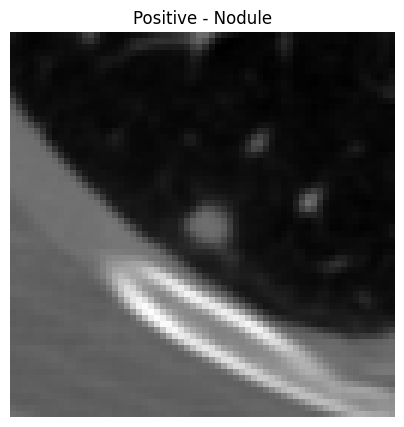

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.imshow(positive_patches[0], cmap="gray")

plt.title("Positive - Nodule")
plt.axis("off")

plt.show()

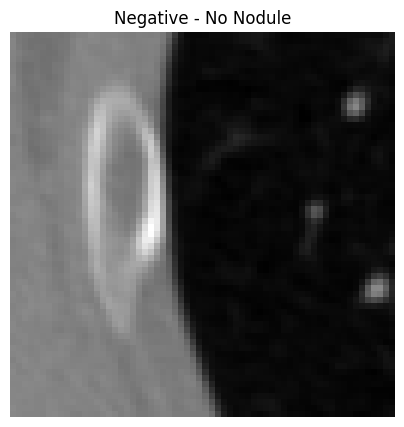

In [ ]:
plt.figure(figsize=(5, 5))

plt.imshow(negative_patches[0], cmap="gray")

plt.title("Negative - No Nodule")
plt.axis("off")

plt.show()

In [ ]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# Positive = 112
positive_data = np.array(positive_patches)

# Randomly select 112 negatives
selected_indices = np.random.choice(
    len(negative_patches),
    size=len(positive_patches),
    replace=False
)

negative_data = np.array(negative_patches)[selected_indices]

print("Positive samples:", len(positive_data))
print("Negative samples:", len(negative_data))

Positive samples: 112
Negative samples: 112


In [ ]:
X = np.concatenate(
    [negative_data, positive_data],
    axis=0
)

y = np.concatenate(
    [
        np.zeros(len(negative_data)),
        np.ones(len(positive_data))
    ]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (224, 64, 64)
y shape: (224,)


In [ ]:
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

print("Dataset shuffled successfully!")

Dataset shuffled successfully!


In [ ]:
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (224, 64, 64, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (156, 64, 64, 1)
Validation: (34, 64, 64, 1)
Testing: (34, 64, 64, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled!")

Model compiled!


In [ ]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=20,
    batch_size=16
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step - accuracy: 0.5256 - loss: 0.6721 - val_accuracy: 0.5882 - val_loss: 0.6373
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6731 - loss: 0.5715 - val_accuracy: 0.7647 - val_loss: 0.5179
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7179 - loss: 0.5386 - val_accuracy: 0.7941 - val_loss: 0.4851
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8077 - loss: 0.4872 - val_accuracy: 0.8529 - val_loss: 0.4897
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8654 - loss: 0.3579 - val_accuracy: 0.8824 - val_loss: 0.4078
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8462 - loss: 0.3530 - val_accuracy: 0.8235 - val_loss: 0.4469
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9038 - loss: 0.2683 - val_accuracy: 0.8529 - val_loss: 0.3139
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9423 - loss: 0.2067 - val_accuracy: 0.8529 -

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8824 - loss: 0.2050 
Test Loss: 0.20500504970550537
Test Accuracy: 0.8823529481887817


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int).flatten()

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Nodule", "Nodule"]
))

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
              precision    recall  f1-score   support

   No Nodule       0.88      0.88      0.88        17
      Nodule       0.88      0.88      0.88        17

    accuracy                           0.88        34
   macro avg       0.88      0.88      0.88        34
weighted avg       0.88      0.88      0.88        34

Confusion Matrix:
[[15  2]
 [ 2 15]]


In [ ]:
model.save(
    "/content/lung_cancer_project/lung_nodule_cnn.keras"
)

print(" Model saved successfully!")

 Model saved successfully!


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8824 - loss: 0.2050
Test Loss: 0.20500504970550537
Test Accuracy: 0.8823529481887817
Test Accuracy (%): 88.23529481887817


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_prob = model.predict(X_test)

y_pred = (y_prob >= 0.5).astype(int).flatten()

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Nodule", "Nodule"]
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
              precision    recall  f1-score   support

   No Nodule       0.88      0.88      0.88        17
      Nodule       0.88      0.88      0.88        17

    accuracy                           0.88        34
   macro avg       0.88      0.88      0.88        34
weighted avg       0.88      0.88      0.88        34



Confusion Matrix:
[[15  2]
 [ 2 15]]


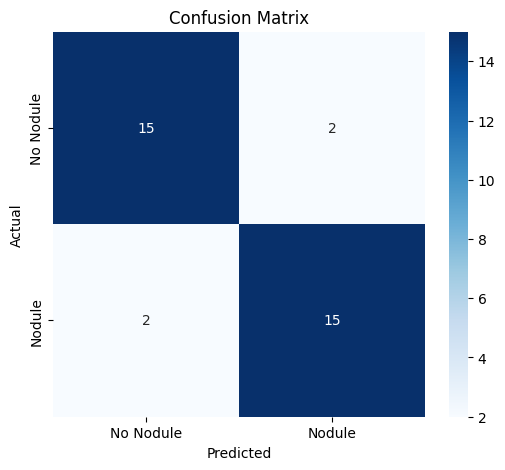

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Nodule", "Nodule"],
    yticklabels=["No Nodule", "Nodule"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix:
[[15  2]
 [ 2 15]]

True Negative (TN): 15
False Positive (FP): 2
False Negative (FN): 2
True Positive (TP): 15

Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.88      0.88      0.88        17
      Nodule       0.88      0.88      0.88        17

    accuracy                           0.88        34
   macro avg       0.88      0.88      0.88        34
weighted avg       0.88      0.88      0.88        34



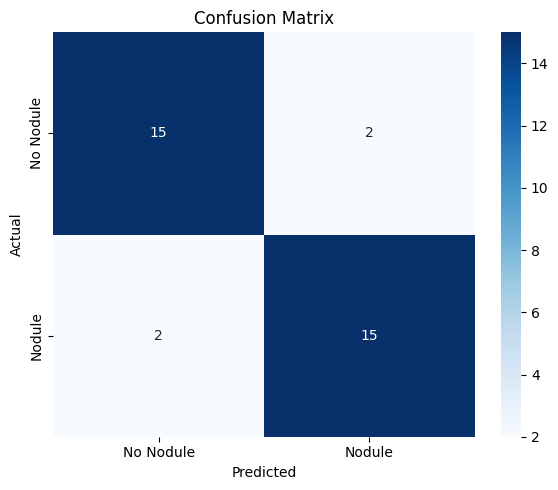

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Extract values
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP): {tp}")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Nodule", "Nodule"]
))

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Nodule", "Nodule"],
    yticklabels=["No Nodule", "Nodule"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")

Sensitivity (Recall): 0.8824
Specificity:          0.8824
